#
# TALLER - TRANSFER LEARNING CON YOLOV8
# DETECCIÓN PERSONALIZADA DE CELULARES


In [1]:


!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.0 MB/s eta 0:00:00


# Verified is there any available GPU

In [16]:
import torch

print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU disponible: True
GPU: Tesla T4


# Unzip the file that contents the dataset

In [3]:
import zipfile
import os

zip_path = "/content/-cell phone-Dataset.v1i.yolov8.zip"

extract_path = "/content/cell_phone_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extraído correctamente")
print(os.listdir(extract_path))

Dataset extraído correctamente
['README.roboflow.txt', 'README.dataset.txt', 'valid', 'test', 'train', 'data.yaml']


# Find the data.yml file

In [4]:
import os

yaml_path = None

for root, dirs, files in os.walk(extract_path):
    if "data.yaml" in files:
        yaml_path = os.path.join(root, "data.yaml")
        break

print("YAML encontrado:")
print(yaml_path)

YAML encontrado:
/content/cell_phone_dataset/data.yaml


# Dataset structure

In [5]:
for root, dirs, files in os.walk(extract_path):
    print(root)

/content/cell_phone_dataset
/content/cell_phone_dataset/valid
/content/cell_phone_dataset/valid/images
/content/cell_phone_dataset/valid/labels
/content/cell_phone_dataset/test
/content/cell_phone_dataset/test/images
/content/cell_phone_dataset/test/labels
/content/cell_phone_dataset/train
/content/cell_phone_dataset/train/images
/content/cell_phone_dataset/train/labels


# Load the pre-training model

In [6]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Training with fifty eppoach

In [7]:
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    project="cell_phone_training",
    name="transfer_learning_yolov8n"
)

Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cell_phone_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=transfer_learning_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

In [8]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1401.2±581.4 MB/s, size: 33.2 KB)
val: Scanning /content/cell_phone_dataset/valid/labels.cache... 63 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 63/63 29.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.5it/s 2.6s
                   all         63         97      0.842      0.897      0.889      0.547
Speed: 15.5ms preprocess, 8.4ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dd1180bd700>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', '

# Search for the results address

In [11]:
!find /content -name "best.pt"
!find /content -name "results.png"

/content/runs/detect/cell_phone_training/transfer_learning_yolov8n/weights/best.pt
/content/runs/detect/cell_phone_training/transfer_learning_yolov8n/results.png


# Show the image address

In [13]:
import os

for f in os.listdir(results_dir):
    print(f)

confusion_matrix_normalized.png
results.png
weights
val_batch1_labels.jpg
val_batch0_labels.jpg
train_batch2.jpg
train_batch1.jpg
args.yaml
val_batch0_pred.jpg
BoxF1_curve.png
train_batch960.jpg
BoxP_curve.png
BoxR_curve.png
val_batch1_pred.jpg
results.csv
train_batch0.jpg
labels.jpg
train_batch962.jpg
train_batch961.jpg
BoxPR_curve.png
confusion_matrix.png


# Show an important image from the training

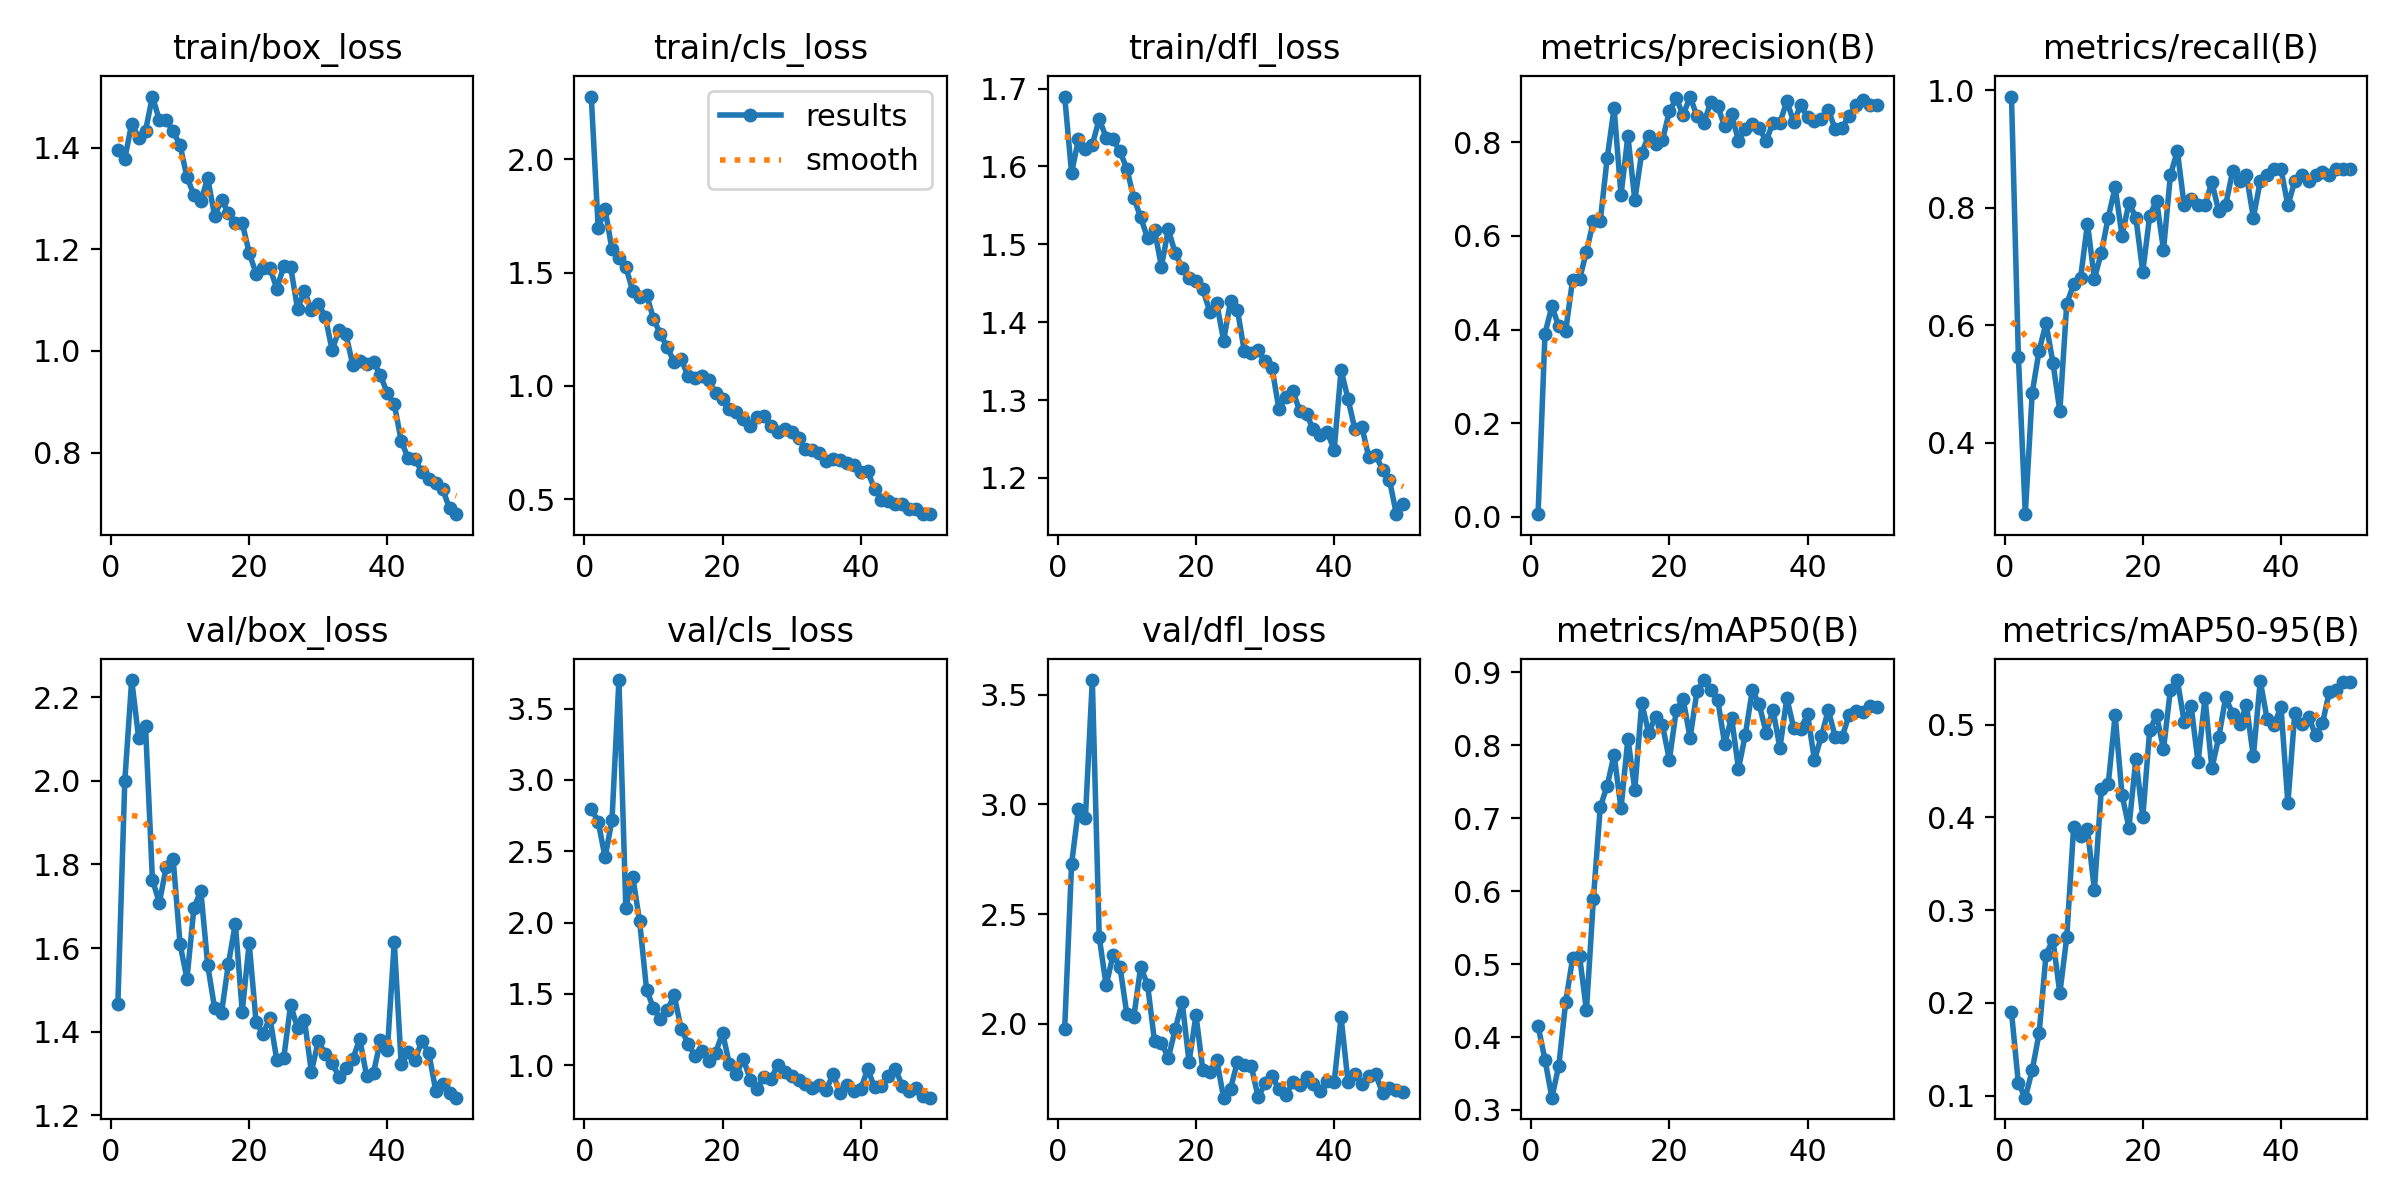

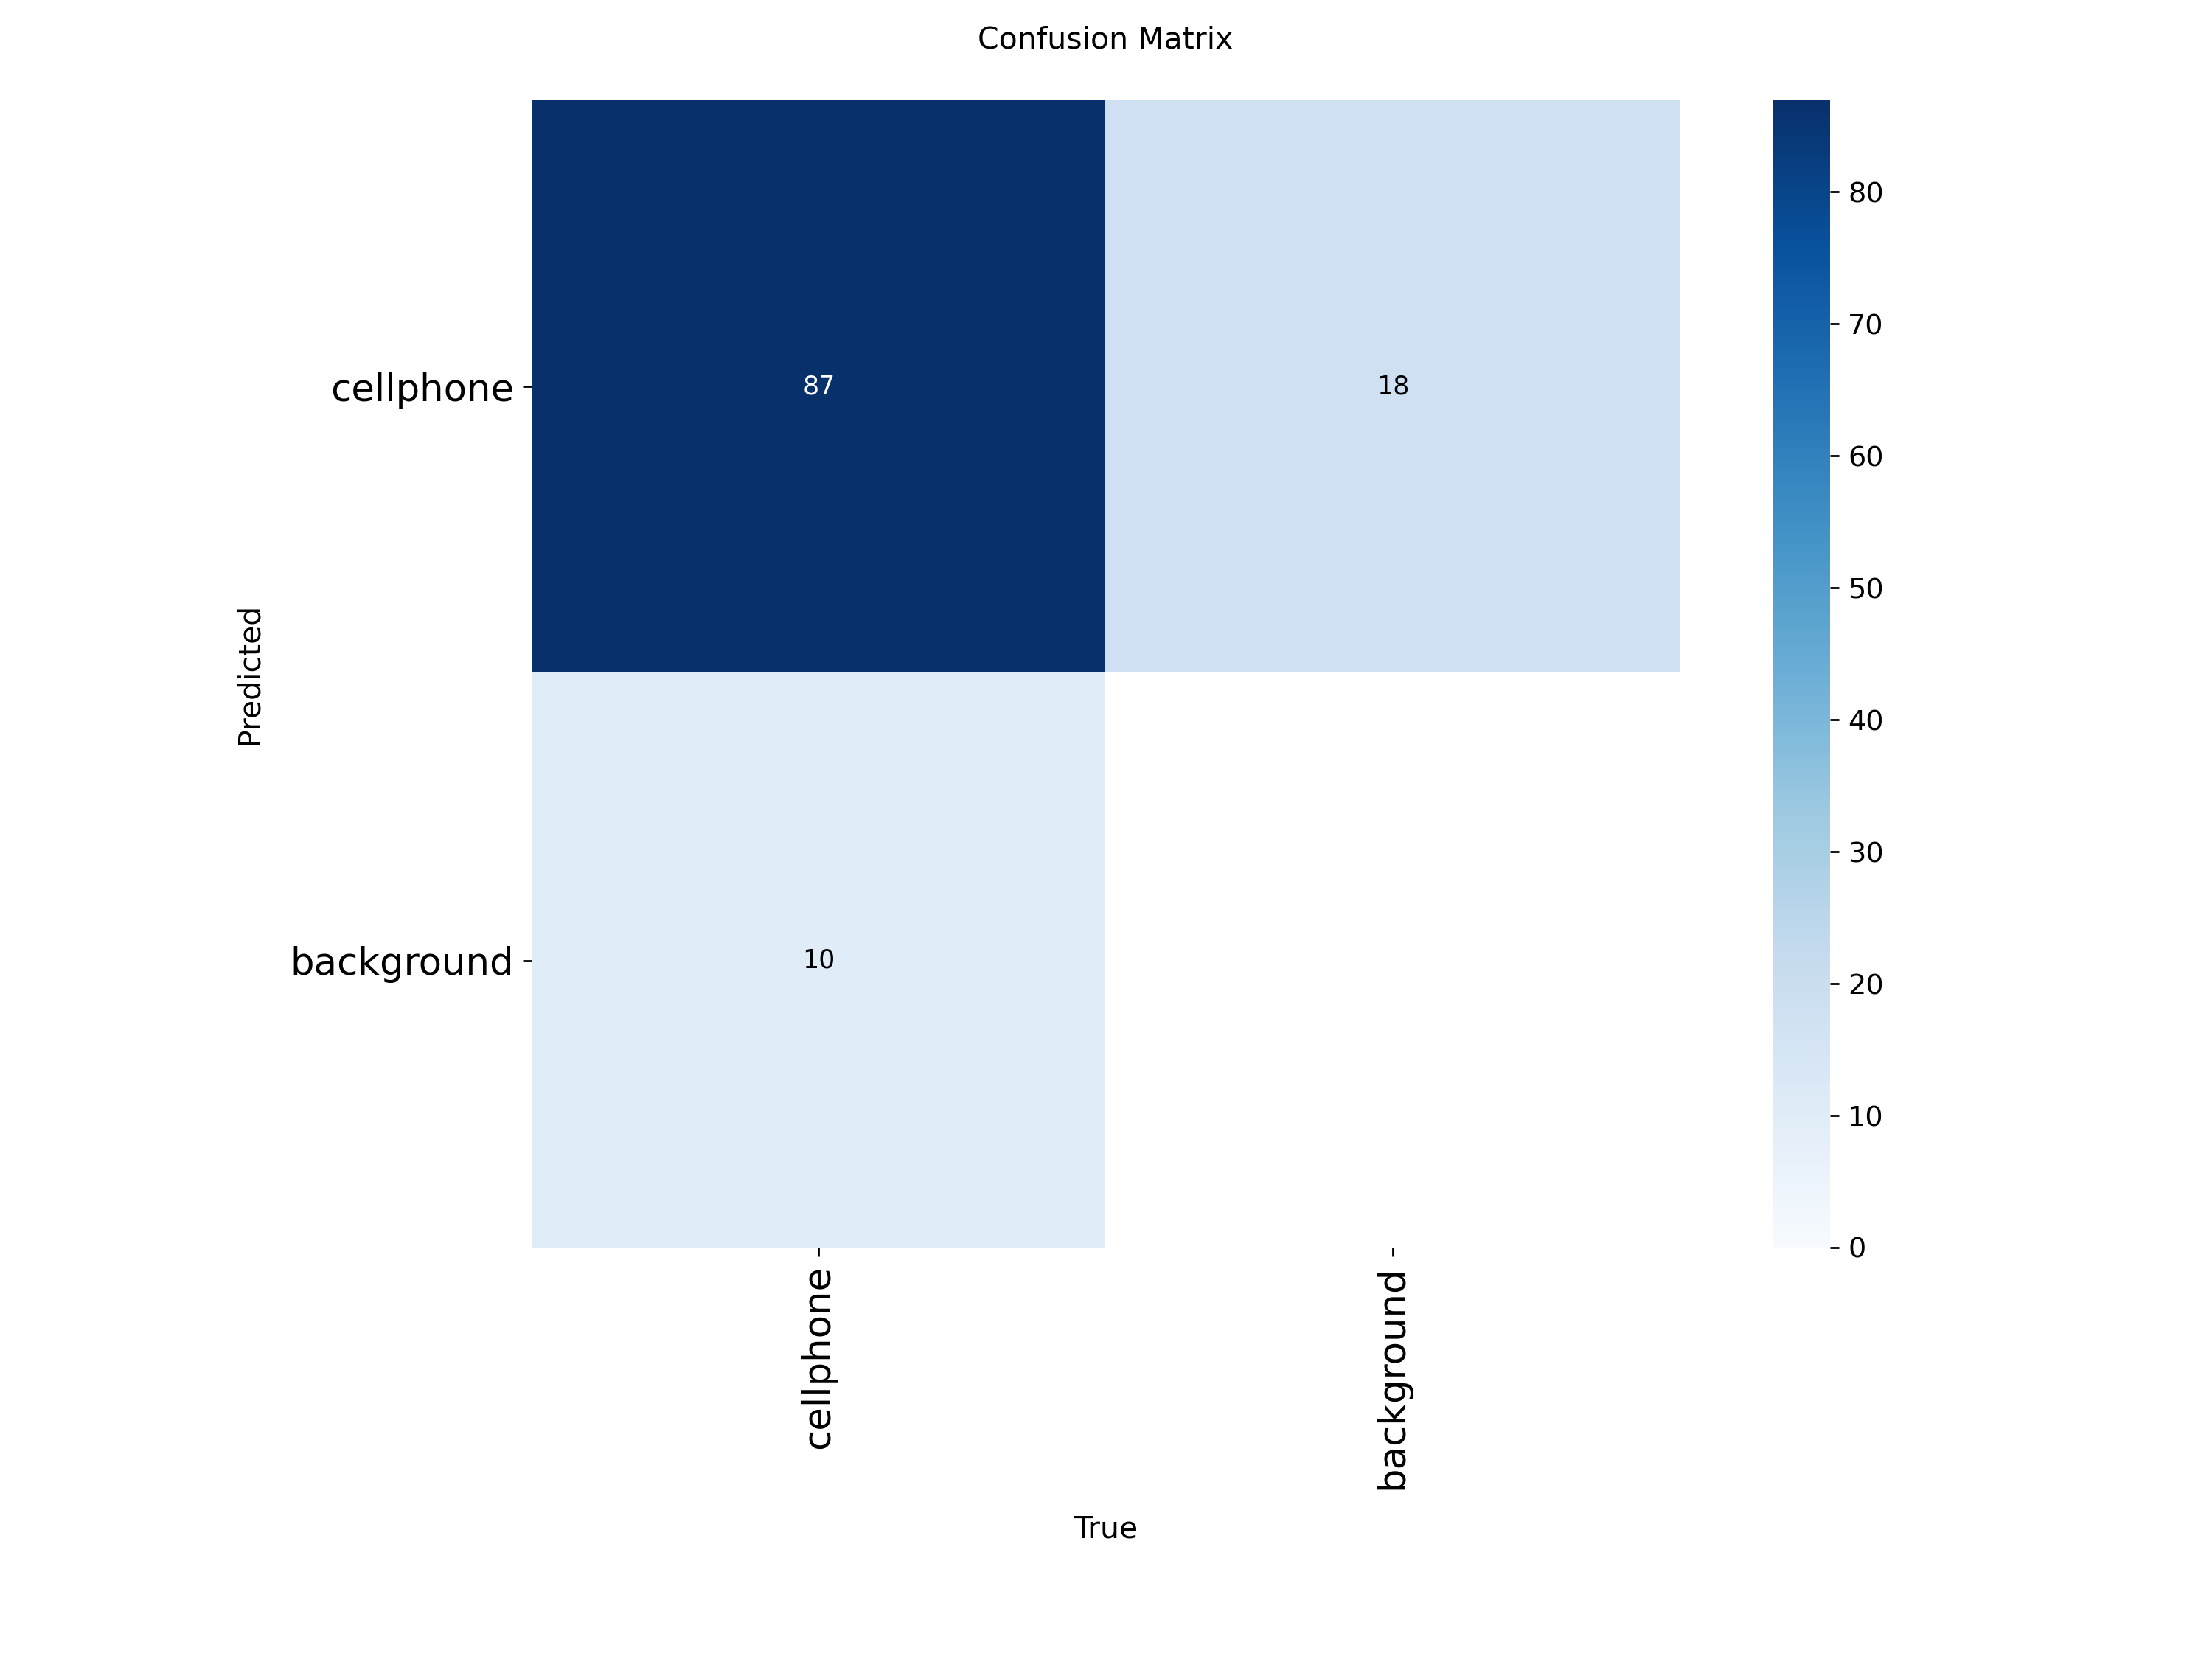

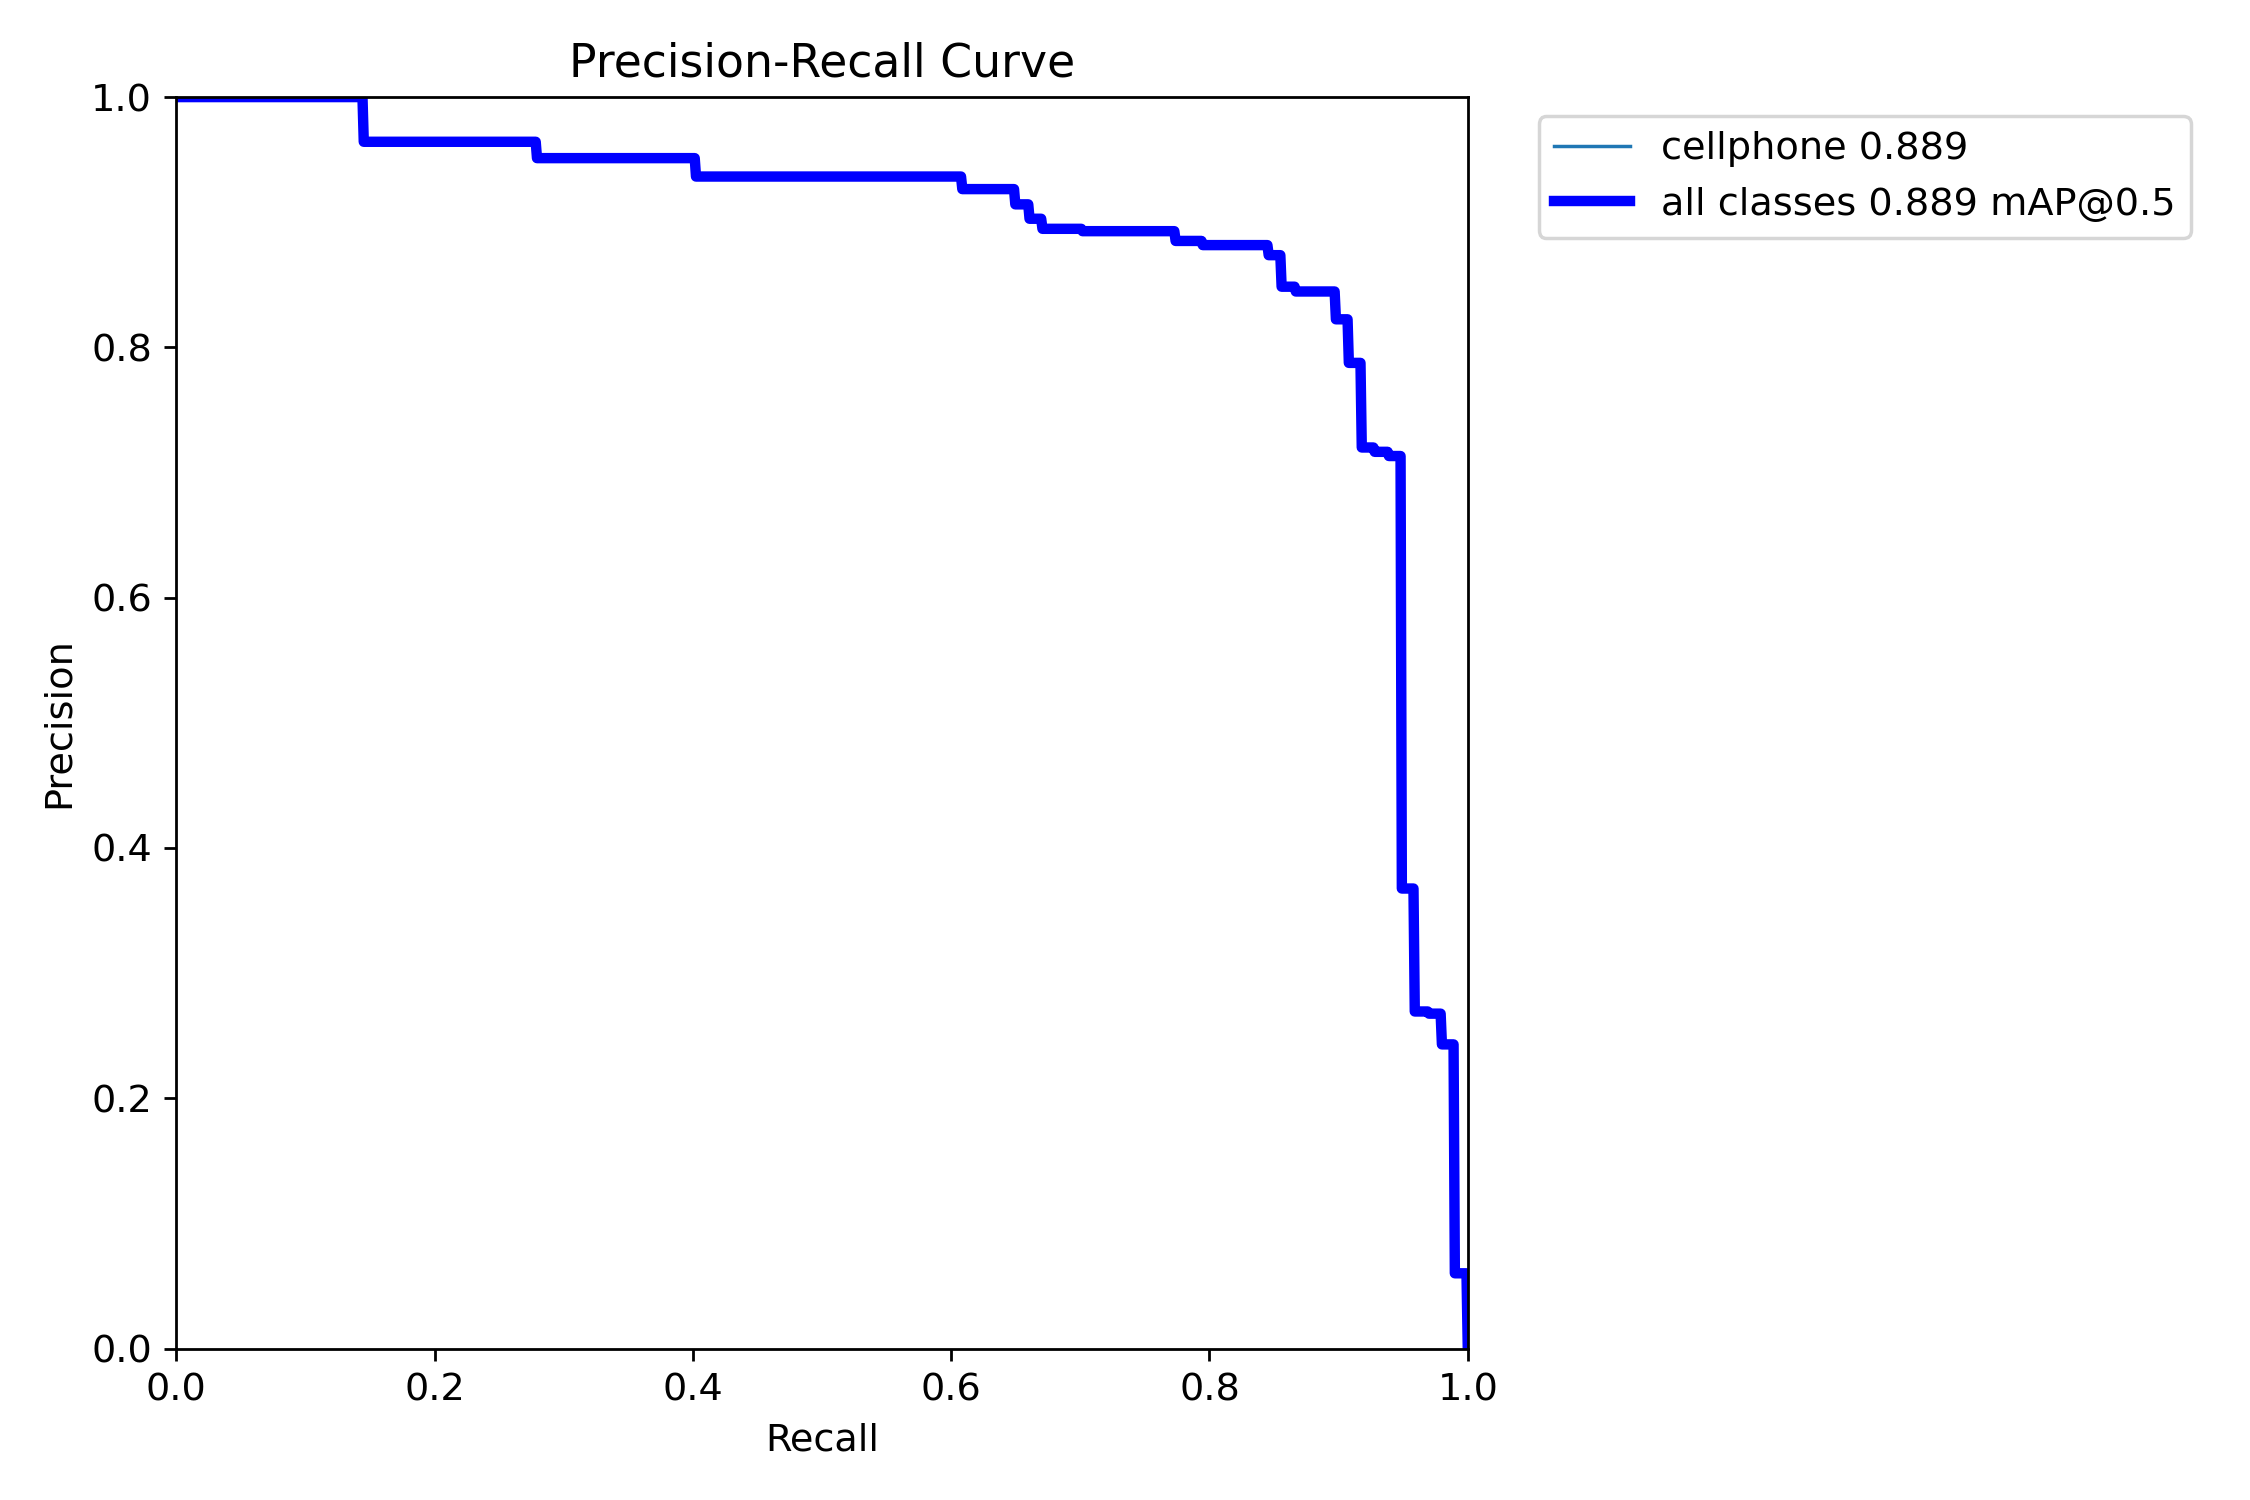

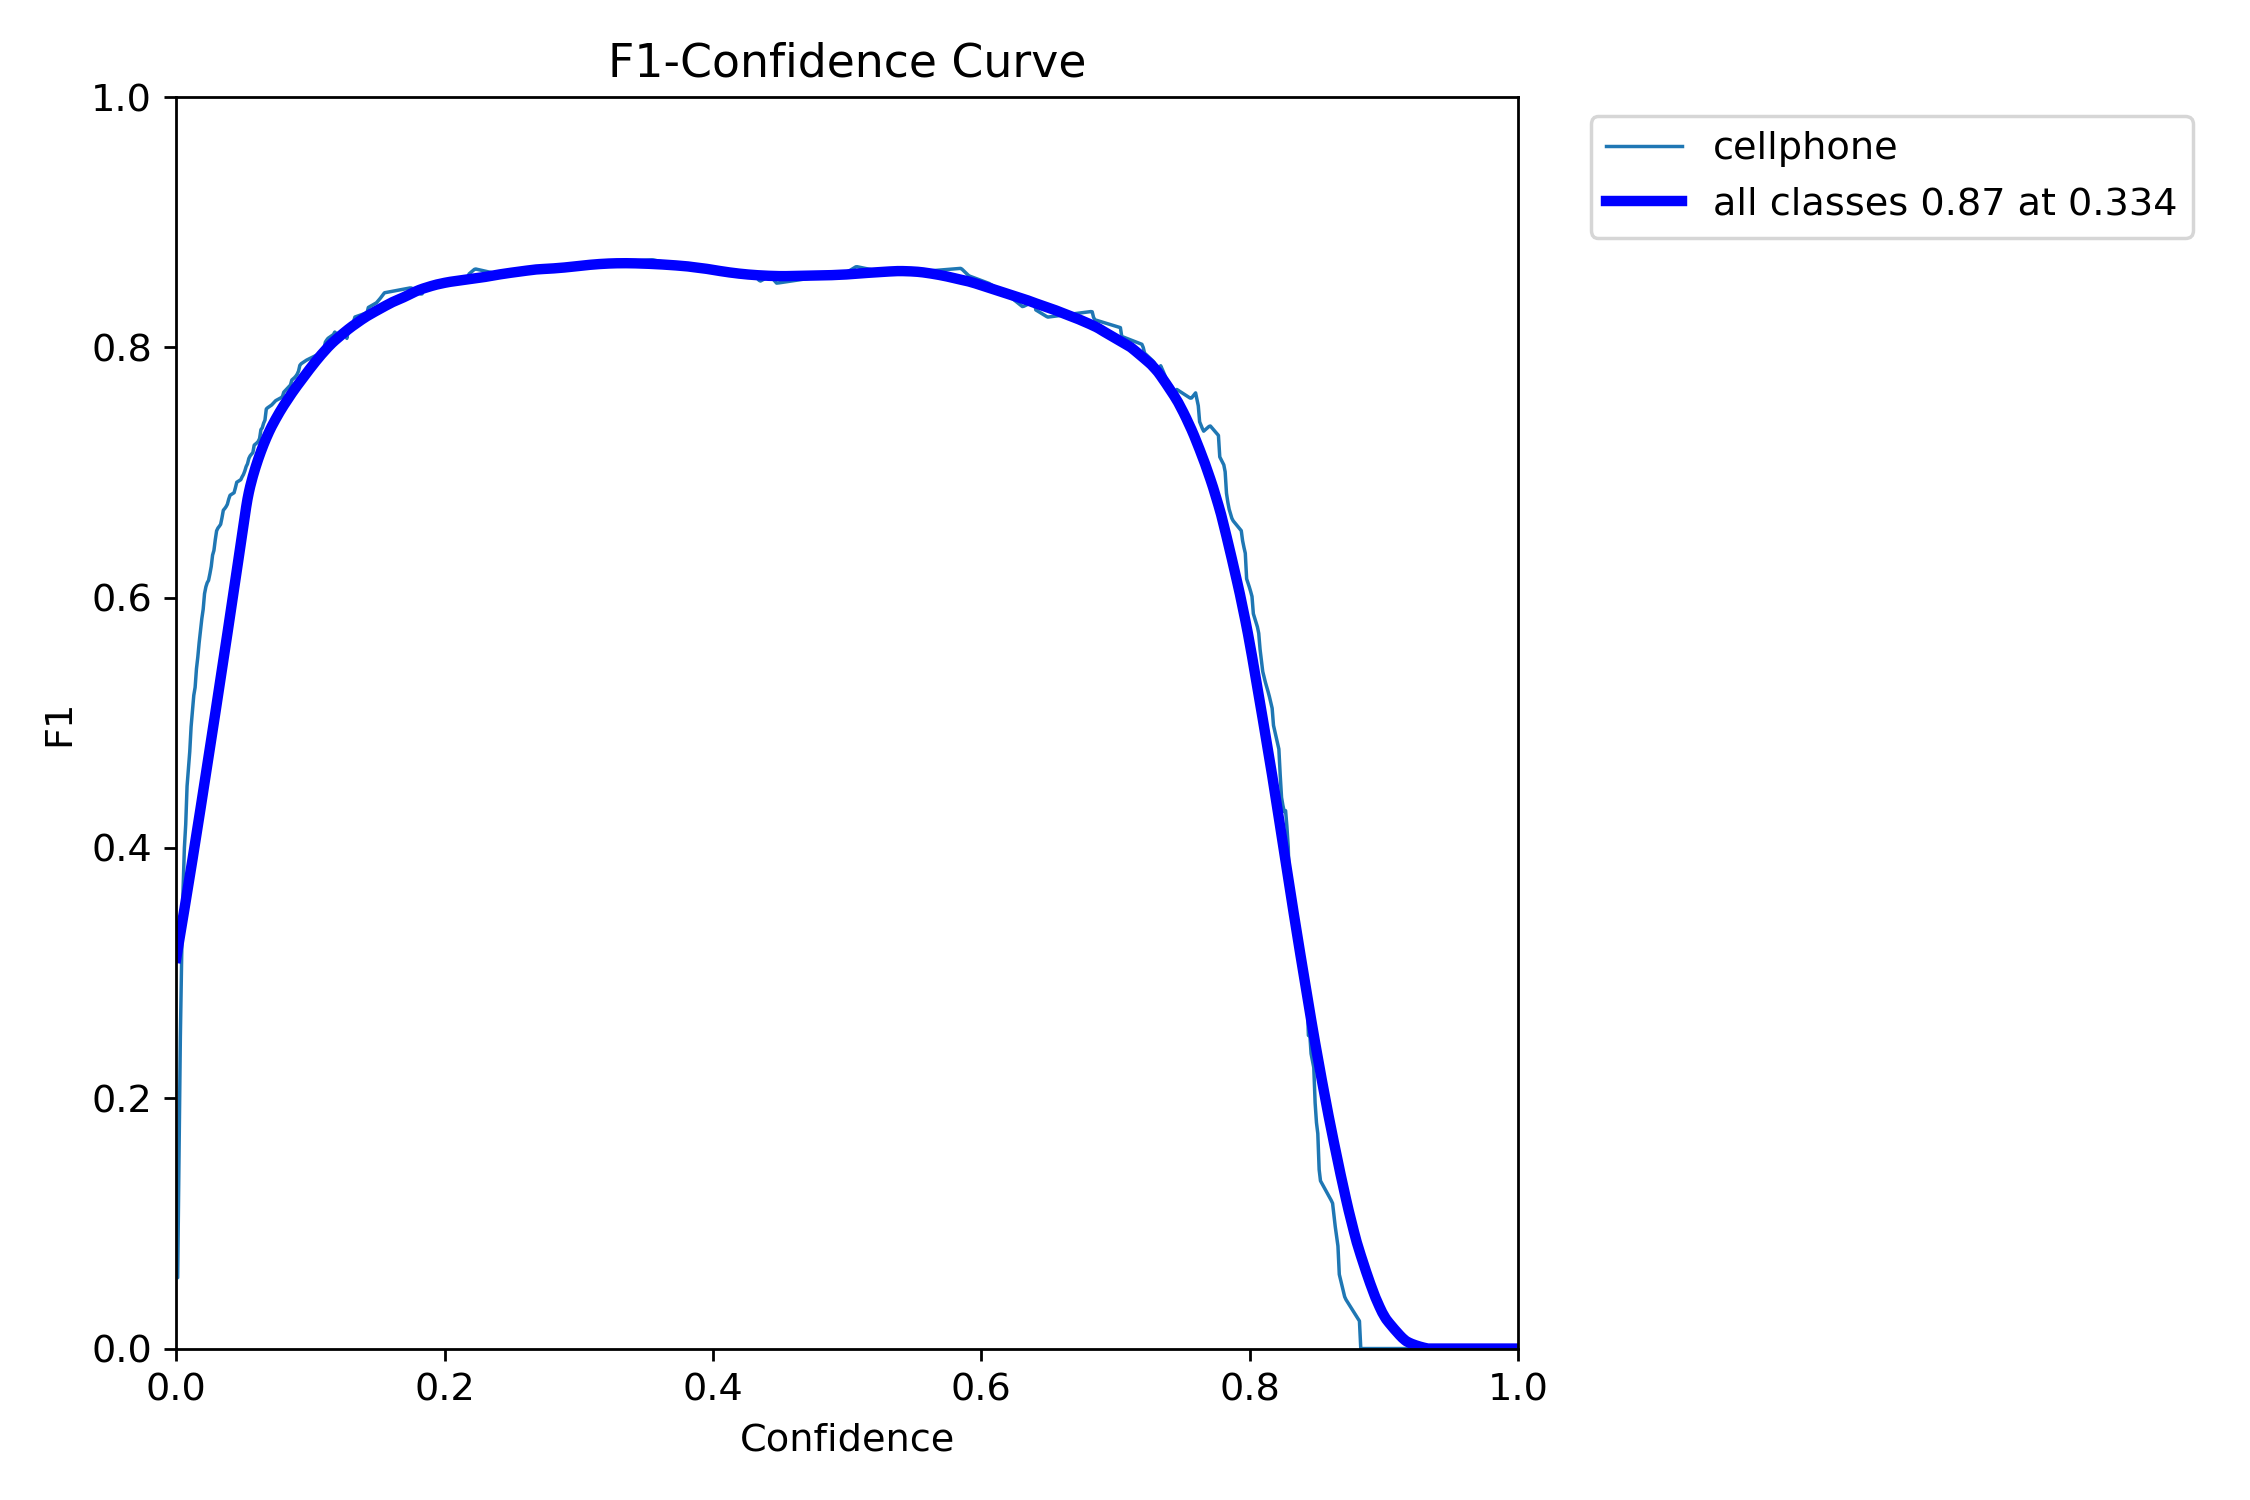

In [14]:
from IPython.display import Image, display

results_dir = "/content/runs/detect/cell_phone_training/transfer_learning_yolov8n"

# Resultados generales del entrenamiento
display(Image(filename=f"{results_dir}/results.png"))

# Matriz de confusión
display(Image(filename=f"{results_dir}/confusion_matrix.png"))

# Curva Precision-Recall
display(Image(filename=f"{results_dir}/BoxPR_curve.png"))

# Curva F1
display(Image(filename=f"{results_dir}/BoxF1_curve.png"))

# Load the best model

In [15]:
best_model = YOLO(
    f"{results_dir}/weights/best.pt"
)

# Upload a new image for testing

In [17]:
from google.colab import files

uploaded = files.upload()

Saving guy_talking_on_the_phone.jpg to guy_talking_on_the_phone.jpg


# Get the filename of the image

In [18]:
test_image = list(uploaded.keys())[0]

print(test_image)

guy_talking_on_the_phone.jpg


# Prediction with custom moel

In [19]:
best_model.predict(
    source=test_image,
    conf=0.25,
    save=True,
    project="predictions",
    name="custom_model"
)


image 1/1 /content/guy_talking_on_the_phone.jpg: 448x640 1 cellphone, 78.4ms
Speed: 3.7ms preprocess, 78.4ms inference, 2.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predictions/custom_model


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'cellphone'}
 obb: None
 orig_img: array([[[207, 207, 207],
         [199, 201, 201],
         [202, 204, 204],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[202, 202, 202],
         [196, 198, 198],
         [200, 202, 202],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[198, 198, 198],
         [191, 193, 193],
         [189, 191, 191],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[ 22,  22,  16],
         [ 19,  19,  13],
         [ 27,  27,  21],
         ...,
         [193, 195, 196],
         [191, 193, 194],
         [192, 194, 195]],
 
        [[ 22,  22,  16],
         [ 19,  19,  13],
         [ 27,  27,  21],
         ...,
         [193, 

# Prediction with a base model

In [20]:
base_model = YOLO("yolov8n.pt")

base_model.predict(
    source=test_image,
    conf=0.25,
    save=True,
    project="predictions",
    name="base_model"
)


image 1/1 /content/guy_talking_on_the_phone.jpg: 448x640 1 person, 2 chairs, 1 cell phone, 17.1ms
Speed: 2.4ms preprocess, 17.1ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predictions/base_model


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

# Show the results

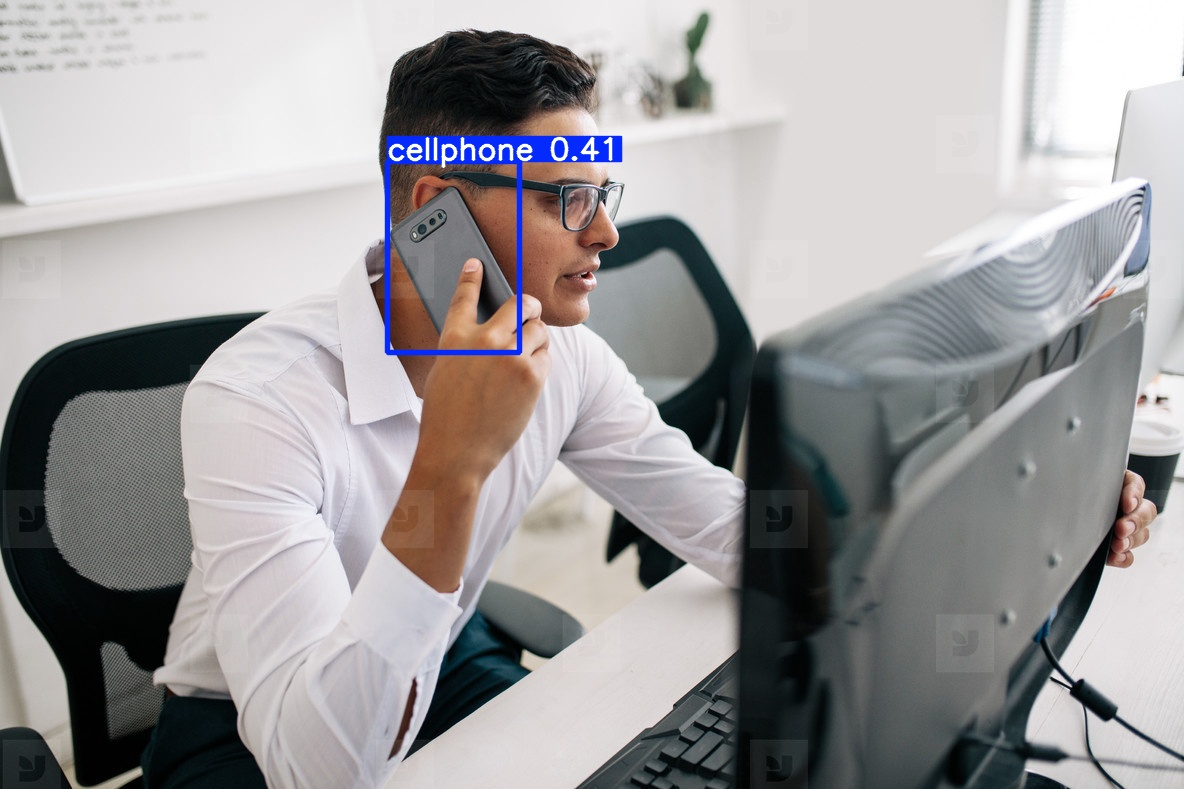

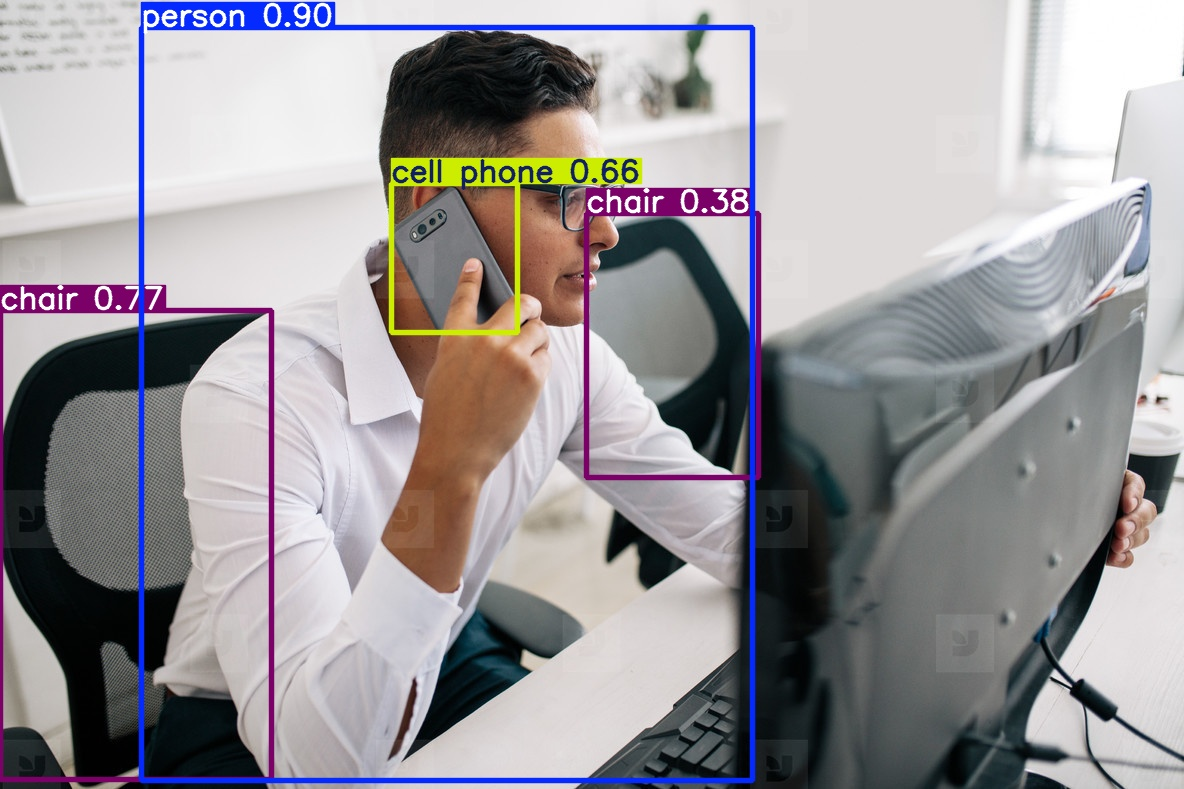

In [24]:
display(Image("/content/runs/detect/predictions/custom_model/" + test_image))
display(Image("/content/runs/detect/predictions/base_model/" + test_image))

# Export the model

In [25]:
best_model.export(format="onnx")

Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/cell_phone_training/transfer_learning_yolov8n/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.82', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 290ms
Prepared 4 packages in 1.46s
Installed 4 packages in 256ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 2.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success 

'/content/runs/detect/cell_phone_training/transfer_learning_yolov8n/weights/best.onnx'